<a href="https://colab.research.google.com/github/glender222/COLAB-EDA/blob/main/EDA-BASIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

from ucimlrepo import fetch_ucirepo

# Recuperamos el dataset
adult = fetch_ucirepo(id=2)

# Obtenemos los datos como dataframes de Pandas
X = adult.data.features
y = adult.data.targets

# metadatos
print(adult.metadata)

# Creamos un único dataset con las características y la variable objetivo
data = pd.concat([X, y], axis=1)

{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [3]:
# ============================================
# 2) INSPECCIÓN INICIAL
# ============================================
print("Dimensiones:", data.shape)
print("\nTipos de datos:")
display(data.dtypes)

print("\nInformación general:")
data.info()

print("\nEstadísticas numéricas:")
display(data.describe())

print("\nEstadísticas de categóricas:")
display(data.describe(include="object"))

print("\nValores nulos por columna:")
display(data.isna().sum())

Dimensiones: (48842, 15)

Tipos de datos:


,0
age,int64
workclass,object
fnlwgt,int64
education,object
education-num,int64
marital-status,object
occupation,object
relationship,object
race,object
sex,object



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

Estadísticas numéricas:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000



Estadísticas de categóricas:


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,47879,48842,48842,47876,48842,48842,48842,48568,48842
unique,9,16,7,15,6,5,2,42,4
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,24720



Valores nulos por columna:


,0
age,0
workclass,963
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,966
relationship,0
race,0
sex,0


In [4]:
# ============================================
# 3) LIMPIEZA BÁSICA DE TEXTO
#    (muy probable por la pista sobre income)
# ============================================
# Quitamos espacios laterales en columnas tipo texto
obj_cols = data.select_dtypes(include="object").columns
for col in obj_cols:
    data[col] = data[col].astype(str).str.strip()

# En Adult suele aparecer >50K. y <=50K. en parte del dataset
if "income" in data.columns:
    data["income"] = data["income"].str.replace(".", "", regex=False).str.strip()

print("Valores únicos de income:")
display(data["income"].value_counts(dropna=False))

Valores únicos de income:


,count
income,
<=50K,37155
>50K,11687


In [5]:
# ============================================
# 4) VALORES MÁS FRECUENTES
# ============================================
def top_frecuentes(df, n=5):
    resultados = []

    for col in df.columns:
        vc = df[col].value_counts(dropna=False).head(n)
        total = len(df)

        for idx, val in vc.items():
            resultados.append({
                "columna": col,
                "valor": idx,
                "frecuencia": val,
                "porcentaje": round(100 * val / total, 2)
            })

    return pd.DataFrame(resultados)

frecuentes = top_frecuentes(data, n=5)
display(frecuentes)

,columna,valor,frecuencia,porcentaje
0,age,36,1348,2.76
1,age,35,1337,2.74
2,age,33,1335,2.73
3,age,23,1329,2.72
4,age,31,1325,2.71
...,...,...,...,...
64,native-country,?,583,1.19
65,native-country,Philippines,295,0.60
66,native-country,nan,274,0.56
67,income,<=50K,37155,76.07


In [6]:
# ============================================
# 5) VALORES ÚNICOS
# ============================================
unicos = pd.DataFrame({
    "columna": data.columns,
    "n_unicos": [data[col].nunique(dropna=False) for col in data.columns],
    "dtype": [data[col].dtype for col in data.columns]
}).sort_values("n_unicos")

display(unicos)

,columna,n_unicos,dtype
14,income,2,object
9,sex,2,object
8,race,5,object
7,relationship,6,object
5,marital-status,7,object
1,workclass,10,object
4,education-num,16,int64
3,education,16,object
6,occupation,16,object
13,native-country,43,object


In [7]:
# ============================================
# 6) DETECCIÓN DE "?" COMO FALTANTES
#    (muy habitual en Adult)
# ============================================
# Primero vemos si hay signos de interrogación
interrogaciones = (data == "?").sum().sort_values(ascending=False)
display(interrogaciones[interrogaciones > 0])

# Reemplazamos ? por NaN
data = data.replace("?", np.nan)

print("Nulos tras reemplazar '?':")
display(data.isna().sum().sort_values(ascending=False))

,0
occupation,1843
workclass,1836
native-country,583


Nulos tras reemplazar '?':


,0
occupation,1843
workclass,1836
native-country,583
fnlwgt,0
education,0
education-num,0
age,0
marital-status,0
relationship,0
sex,0


In [8]:
# ============================================
# 7) DATOS DUPLICADOS
# ============================================
duplicados = data.duplicated().sum()
print("Número de filas duplicadas:", duplicados)

# Si quieres inspeccionarlos:
display(data[data.duplicated()].head())

Número de filas duplicadas: 48


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
4881,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
5104,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
9171,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
11631,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
13084,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K


In [9]:
# ============================================
# 8) RESUMEN DE CALIDAD DE DATOS
# ============================================
resumen_calidad = pd.DataFrame({
    "dtype": data.dtypes,
    "nulos": data.isna().sum(),
    "pct_nulos": (data.isna().mean() * 100).round(2),
    "n_unicos": data.nunique(dropna=False)
}).sort_values(["pct_nulos", "n_unicos"], ascending=[False, True])

display(resumen_calidad)

,dtype,nulos,pct_nulos,n_unicos
occupation,object,1843,3.77,16
workclass,object,1836,3.76,10
native-country,object,583,1.19,43
sex,object,0,0.00,2
income,object,0,0.00,2
race,object,0,0.00,5
relationship,object,0,0.00,6
marital-status,object,0,0.00,7
education,object,0,0.00,16
education-num,int64,0,0.00,16


In [10]:
# ============================================
# 9) OUTLIERS CON IQR
# ============================================
num_cols = data.select_dtypes(include=np.number).columns

def detectar_outliers_iqr(df, cols):
    filas = []

    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr

        mask = (df[col] < lim_inf) | (df[col] > lim_sup)
        n_out = mask.sum()

        filas.append({
            "columna": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lim_inf": lim_inf,
            "lim_sup": lim_sup,
            "n_outliers": n_out,
            "pct_outliers": round(100 * n_out / len(df), 2)
        })

    return pd.DataFrame(filas).sort_values("pct_outliers", ascending=False)

outliers_iqr = detectar_outliers_iqr(data, num_cols)
display(outliers_iqr)

,columna,Q1,Q3,IQR,lim_inf,lim_sup,n_outliers,pct_outliers
5,hours-per-week,40.0,45.0,5.0,32.50,52.50,13496,27.63
3,capital-gain,0.0,0.0,0.0,0.00,0.00,4035,8.26
4,capital-loss,0.0,0.0,0.0,0.00,0.00,2282,4.67
2,education-num,9.0,12.0,3.0,4.50,16.50,1794,3.67
1,fnlwgt,117550.5,237642.0,120091.5,-62586.75,417779.25,1453,2.97
0,age,28.0,48.0,20.0,-2.00,78.00,216,0.44


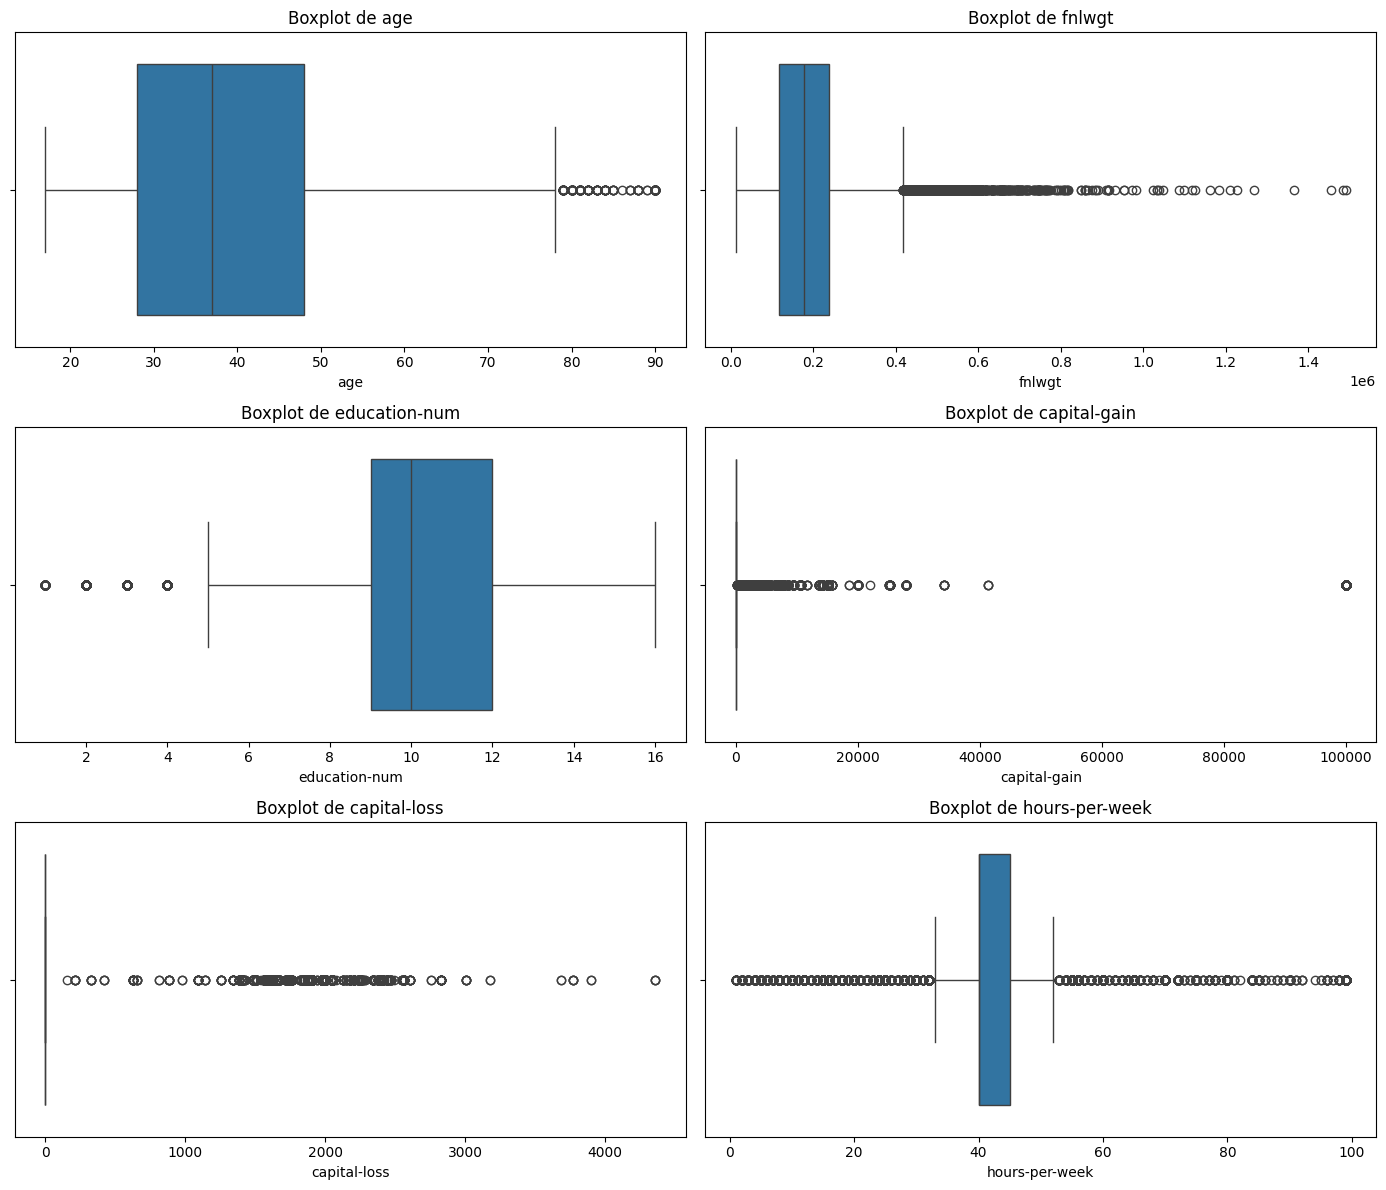

In [11]:
# ============================================
# 10) BOXPLOTS PARA NUMÉRICAS
# ============================================
n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, num_cols):
    sns.boxplot(x=data[col], ax=ax)
    ax.set_title(f"Boxplot de {col}")

for i in range(len(num_cols), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

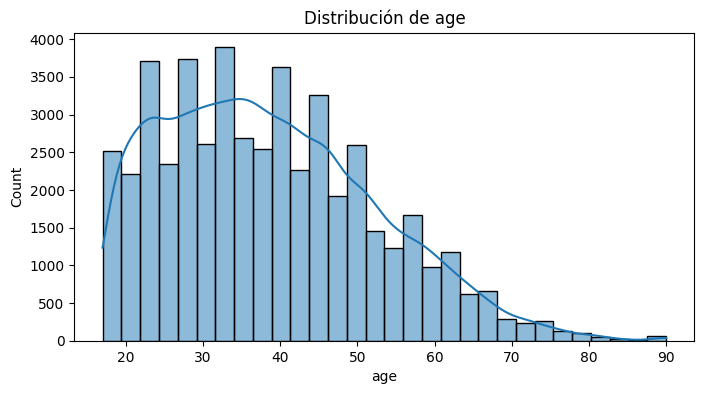

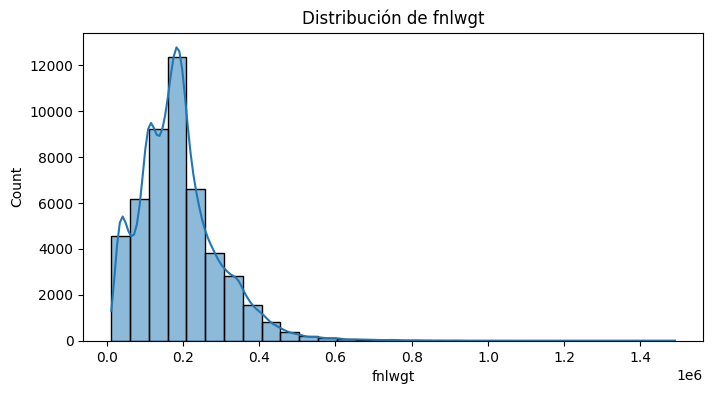

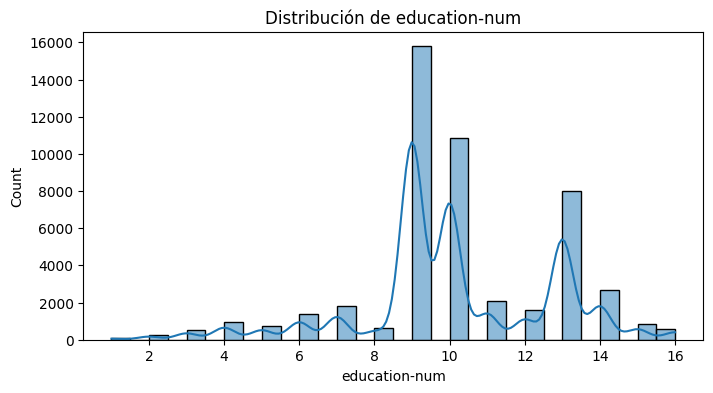

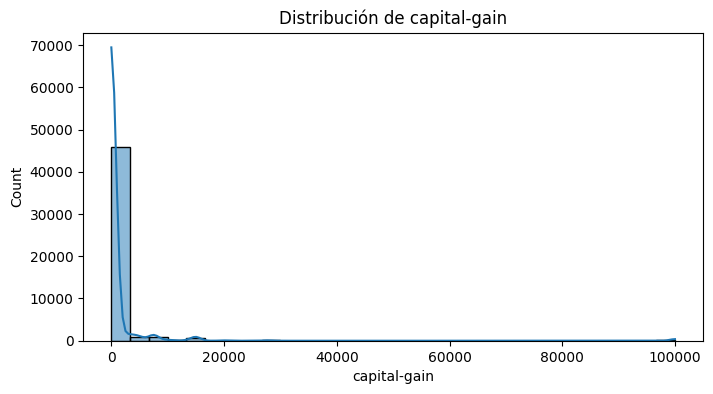

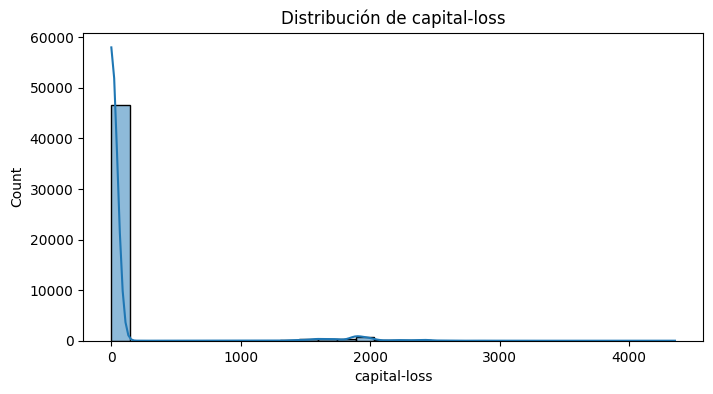

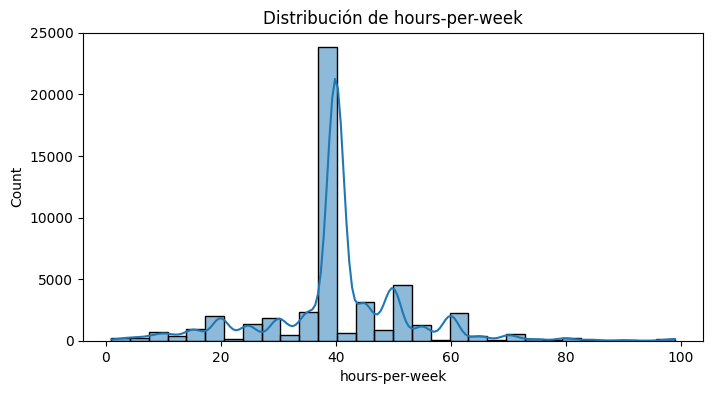

In [12]:
# ============================================
# 11) ANÁLISIS UNIVARIANTE - NUMÉRICAS
# ============================================
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=data, x=col, kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.show()

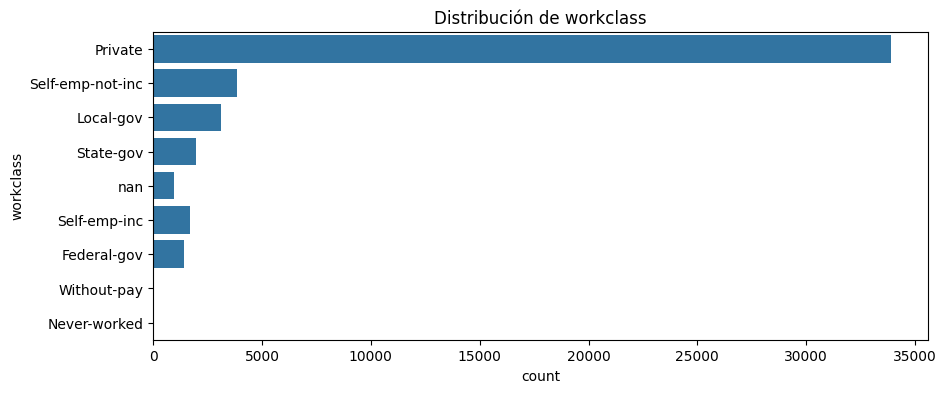

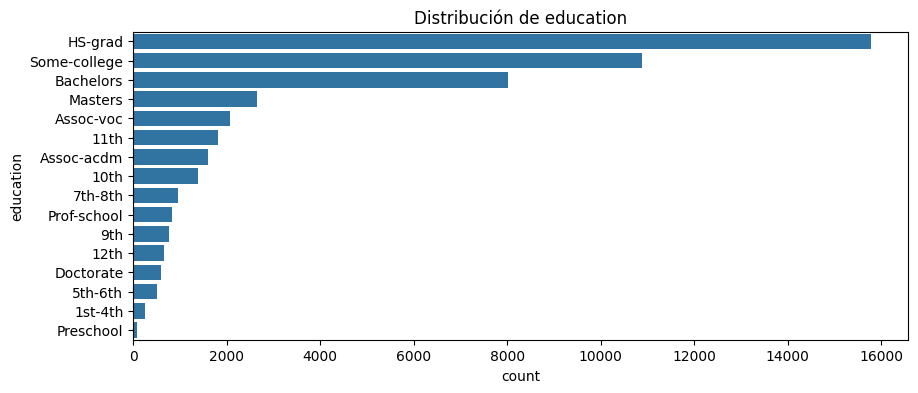

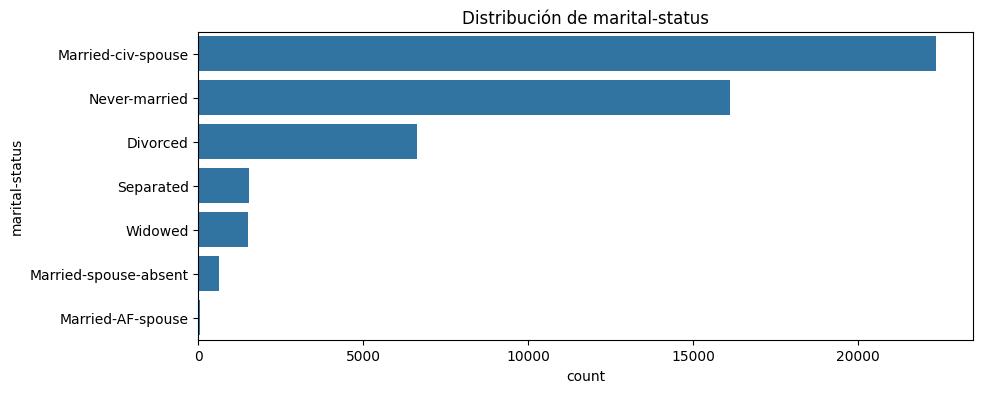

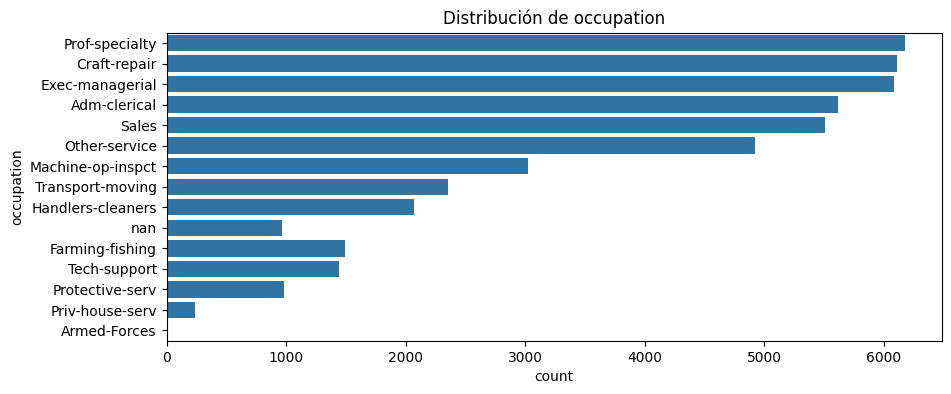

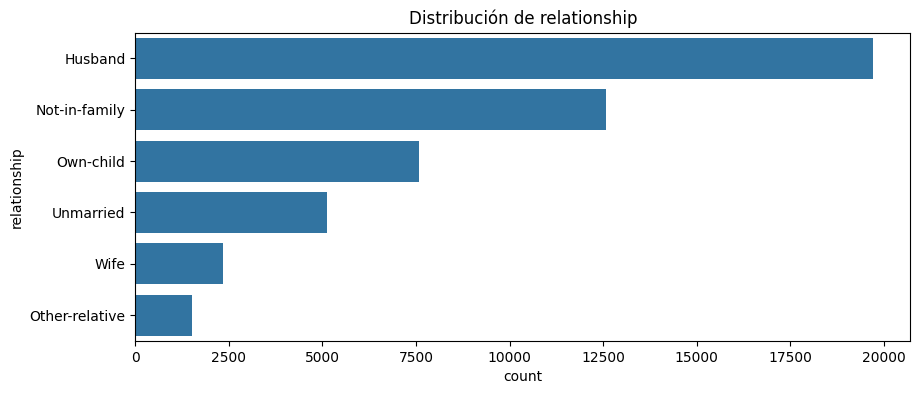

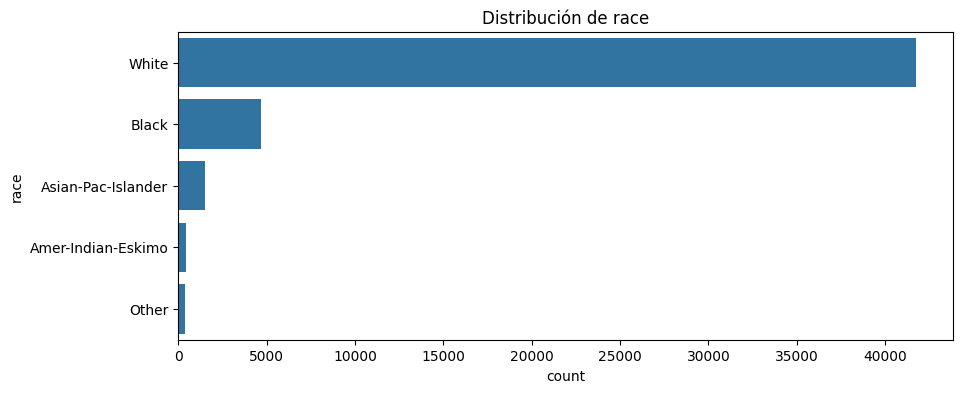

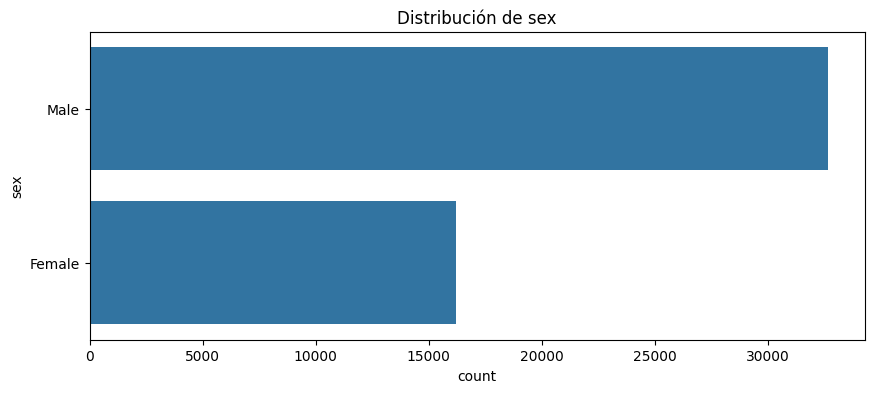

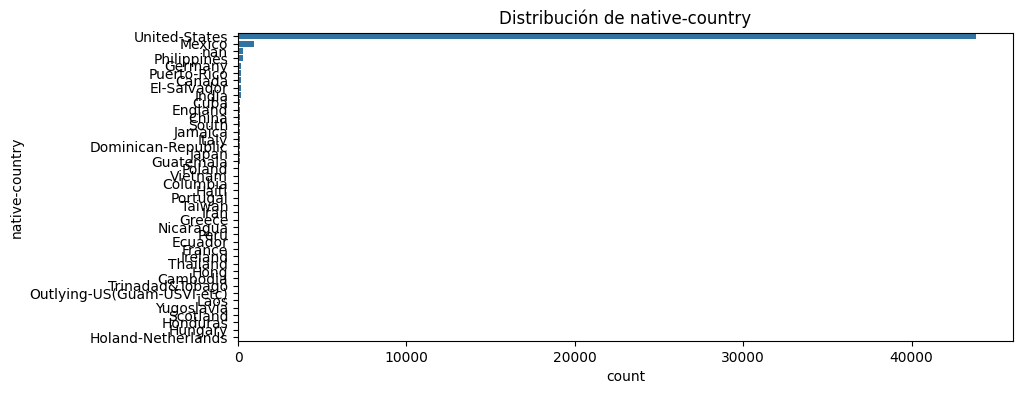

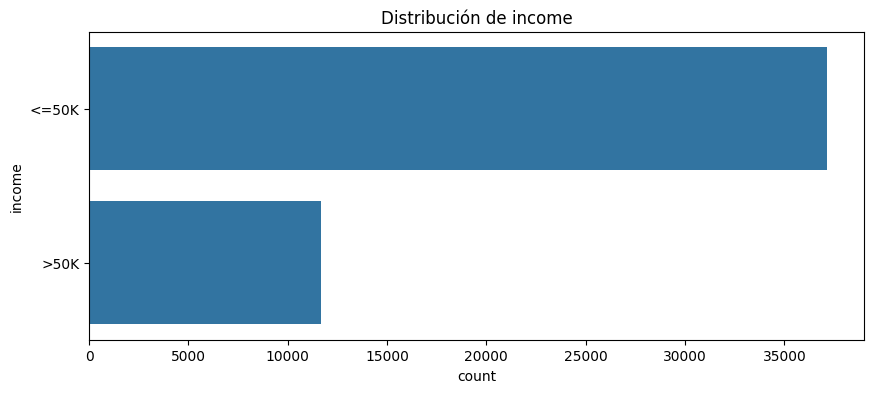

In [13]:
# ============================================
# 12) ANÁLISIS UNIVARIANTE - CATEGÓRICAS
# ============================================
cat_cols = data.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(10, 4))
    orden = data[col].value_counts(dropna=False).index
    sns.countplot(data=data, y=col, order=orden)
    plt.title(f"Distribución de {col}")
    plt.show()

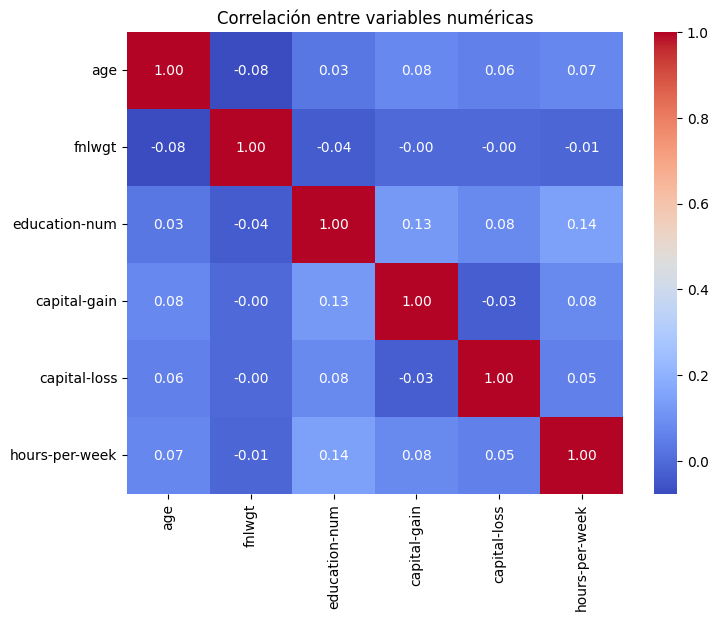

In [14]:
# ============================================
# 13) CORRELACIÓN ENTRE NUMÉRICAS
# ============================================
corr = data[num_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre variables numéricas")
plt.show()

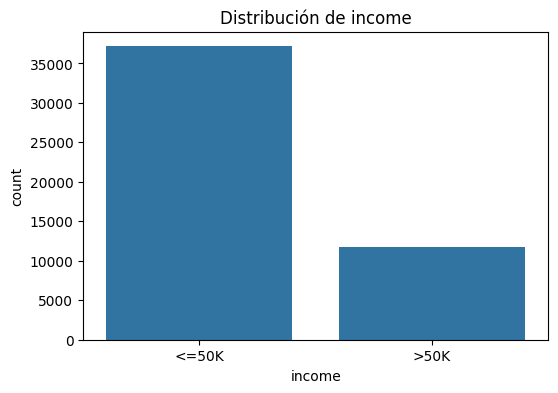

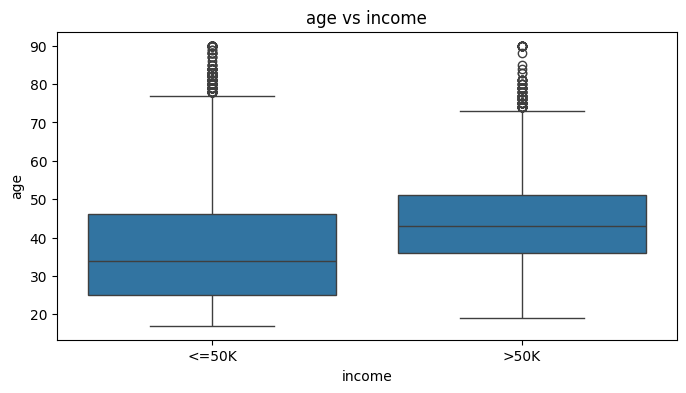

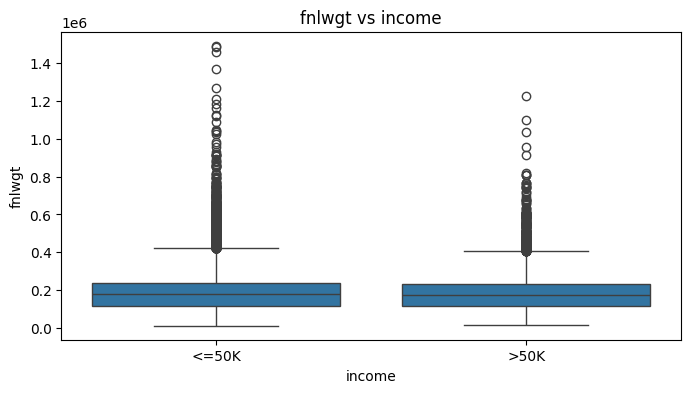

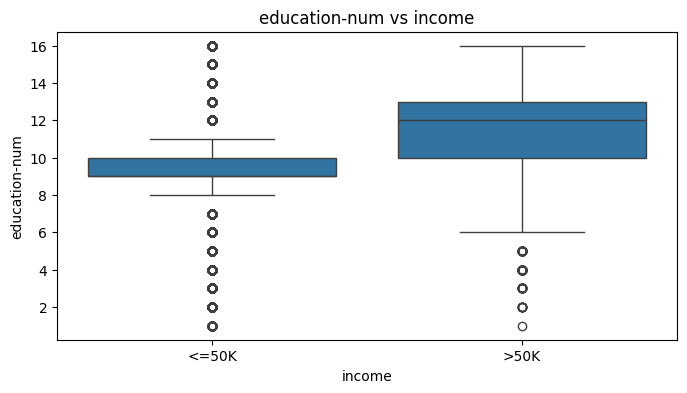

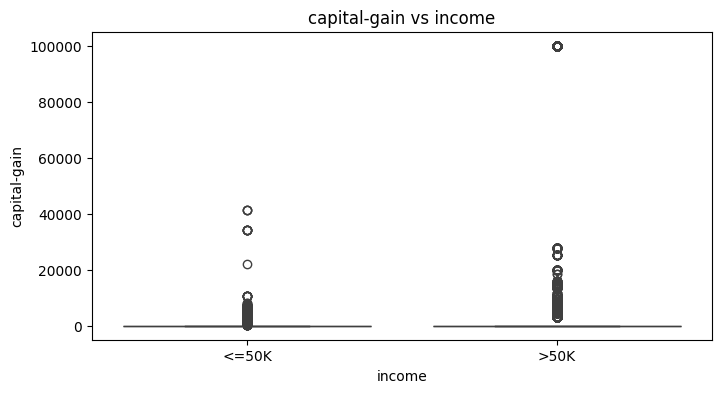

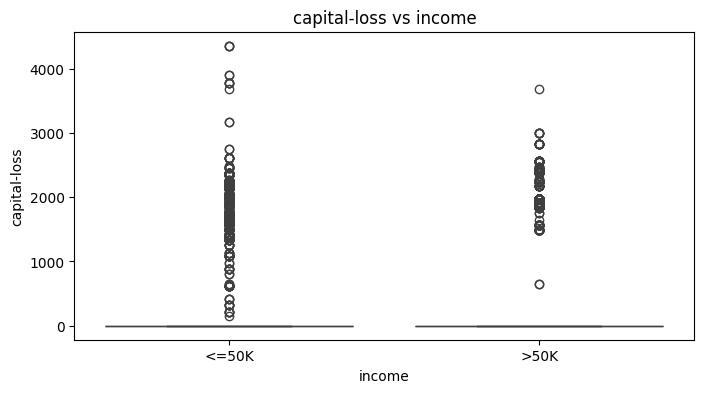

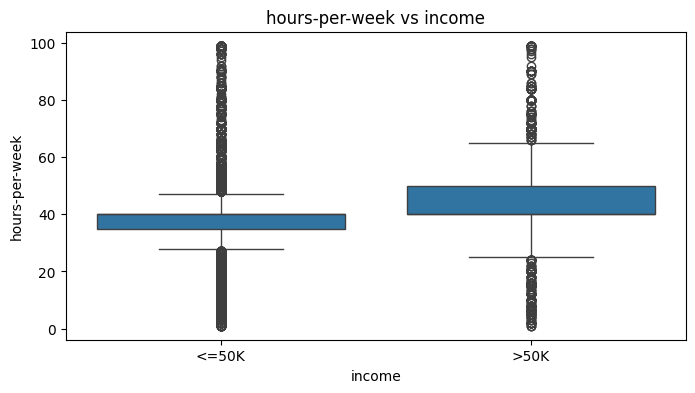

In [15]:
# ============================================
# 14) ANÁLISIS BIVARIANTE CON income
# ============================================
# Aseguramos income limpia
data["income"] = data["income"].astype(str).str.strip().str.replace(".", "", regex=False)

# Distribución de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="income")
plt.title("Distribución de income")
plt.show()

# Numéricas vs income
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=data, x="income", y=col)
    plt.title(f"{col} vs income")
    plt.show()

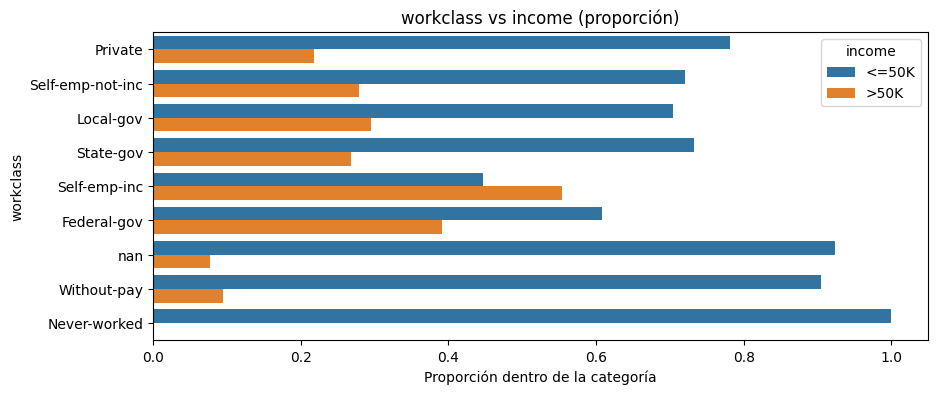

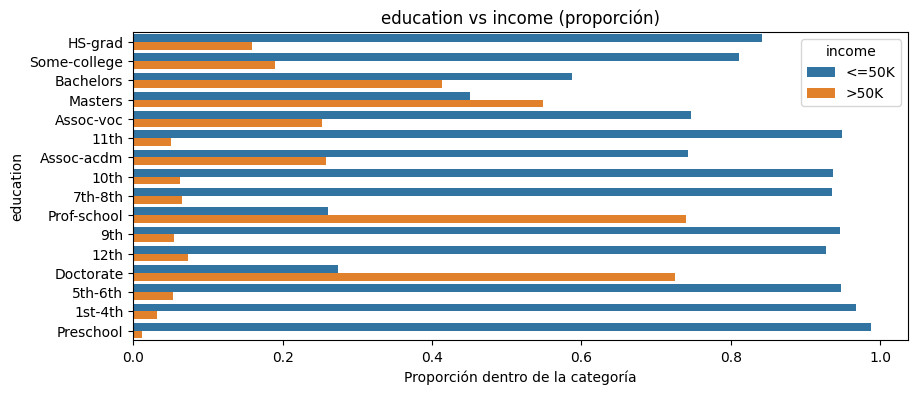

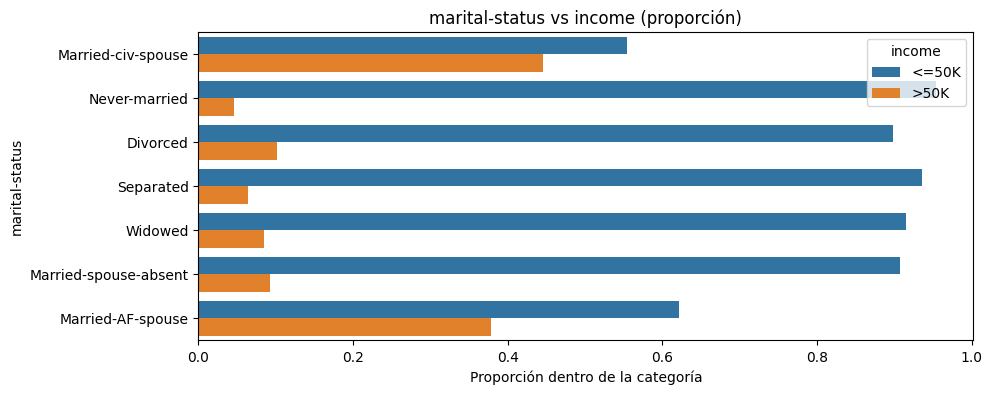

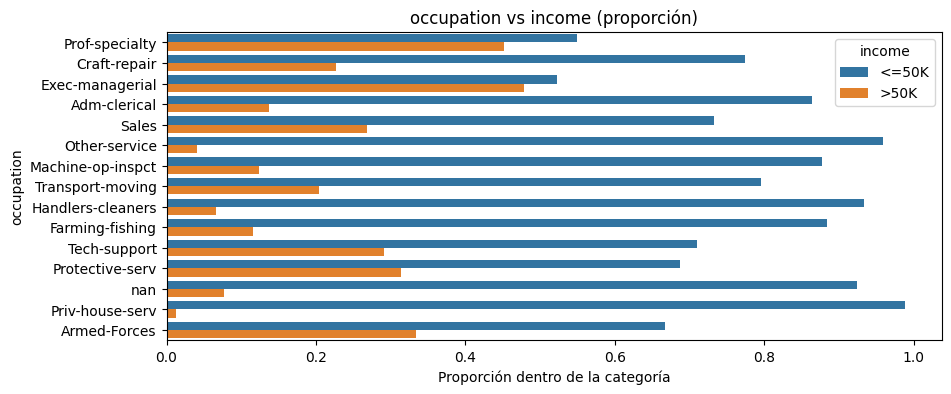

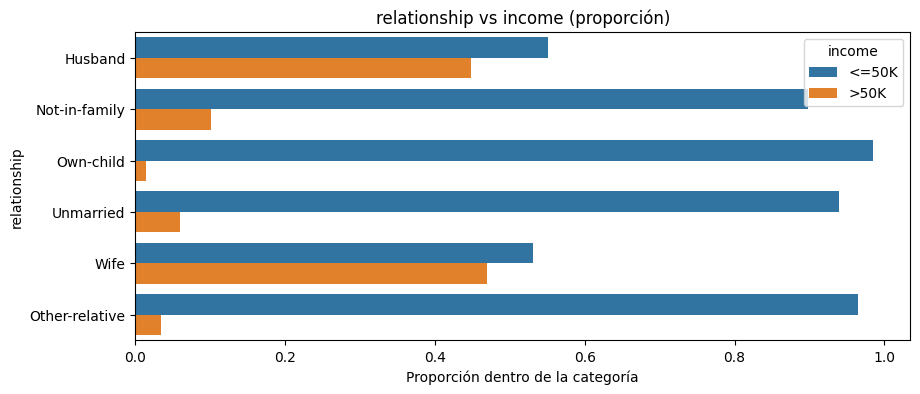

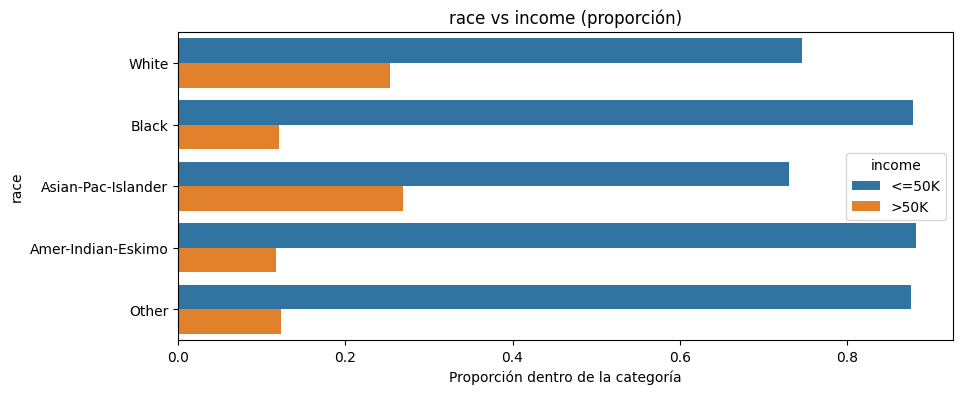

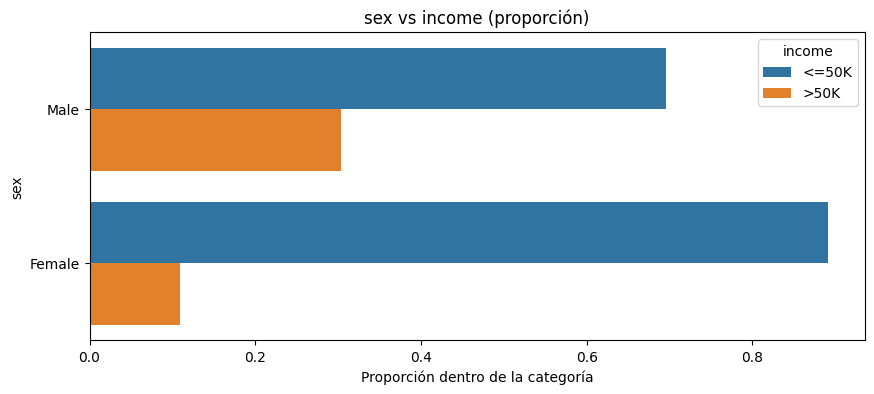

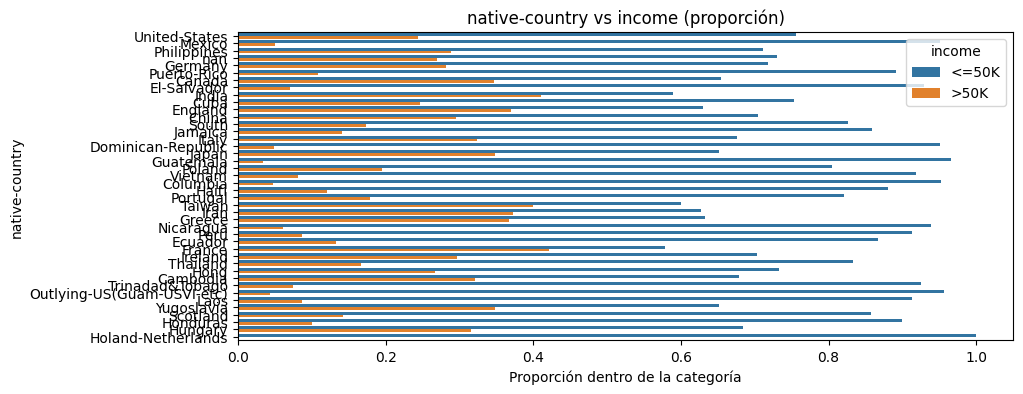

In [16]:
# ============================================
# 15) CATEGÓRICAS VS income
# ============================================
for col in cat_cols:
    if col == "income":
        continue

    tabla = (
        data.groupby([col, "income"])
        .size()
        .reset_index(name="conteo")
    )

    # porcentaje dentro de cada categoría
    tabla["pct"] = tabla.groupby(col)["conteo"].transform(lambda x: x / x.sum())

    orden = data[col].value_counts().index

    plt.figure(figsize=(10, 4))
    sns.barplot(data=tabla, y=col, x="pct", hue="income", order=orden)
    plt.title(f"{col} vs income (proporción)")
    plt.xlabel("Proporción dentro de la categoría")
    plt.show()

/tmp/ipykernel_558/4293541624.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["age_group", "income"])
/tmp/ipykernel_558/4293541624.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_age["pct"] = tabla_age.groupby("age_group")["conteo"].transform(lambda x: x / x.sum())


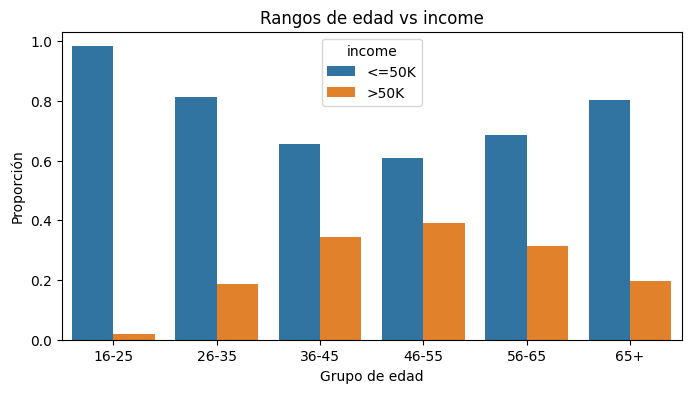

In [17]:
# ============================================
# 16) EDAD EN RANGOS
#    (el artículo sugiere cuantizar age)
# ============================================
bins = [15, 25, 35, 45, 55, 65, 100]
labels = ["16-25", "26-35", "36-45", "46-55", "56-65", "65+"]

data["age_group"] = pd.cut(data["age"], bins=bins, labels=labels)

tabla_age = (
    data.groupby(["age_group", "income"])
    .size()
    .reset_index(name="conteo")
)
tabla_age["pct"] = tabla_age.groupby("age_group")["conteo"].transform(lambda x: x / x.sum())

plt.figure(figsize=(8, 4))
sns.barplot(data=tabla_age, x="age_group", y="pct", hue="income")
plt.title("Rangos de edad vs income")
plt.xlabel("Grupo de edad")
plt.ylabel("Proporción")
plt.show()

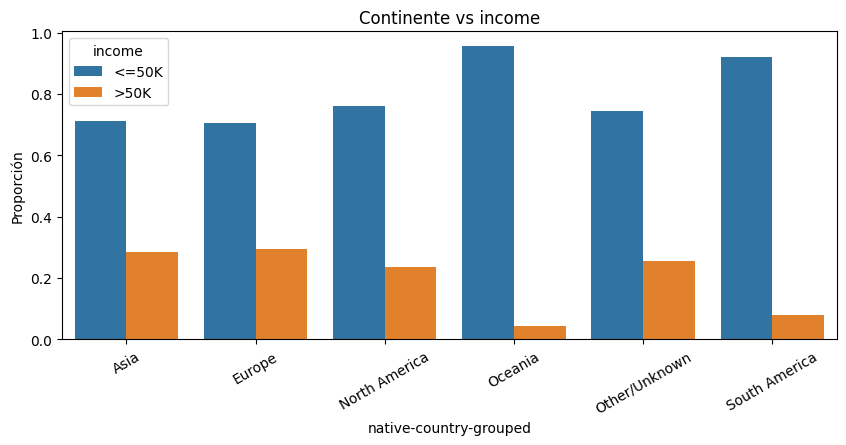

In [18]:
# ============================================
# 17) AGRUPAR native-country
#    (también sugerido por el artículo)
# ============================================
continente = {
    "United-States": "North America",
    "Canada": "North America",
    "Mexico": "North America",
    "Cuba": "North America",
    "Dominican-Republic": "North America",
    "Jamaica": "North America",
    "Puerto-Rico": "North America",
    "Haiti": "North America",
    "Honduras": "North America",
    "Guatemala": "North America",
    "Nicaragua": "North America",
    "El-Salvador": "North America",
    "Trinadad&Tobago": "North America",
    "Ecuador": "South America",
    "Peru": "South America",
    "Columbia": "South America",
    "England": "Europe",
    "Germany": "Europe",
    "Greece": "Europe",
    "Holand-Netherlands": "Europe",
    "Hungary": "Europe",
    "Ireland": "Europe",
    "Italy": "Europe",
    "Poland": "Europe",
    "Portugal": "Europe",
    "Scotland": "Europe",
    "Yugoslavia": "Europe",
    "France": "Europe",
    "Iran": "Asia",
    "India": "Asia",
    "Japan": "Asia",
    "China": "Asia",
    "Hong": "Asia",
    "Cambodia": "Asia",
    "Laos": "Asia",
    "Philippines": "Asia",
    "Thailand": "Asia",
    "Taiwan": "Asia",
    "Vietnam": "Asia",
    "South": "Asia",
    "Outlying-US(Guam-USVI-etc)": "Oceania"
}

data["native-country-grouped"] = data["native-country"].map(continente).fillna("Other/Unknown")

tabla_country = (
    data.groupby(["native-country-grouped", "income"])
    .size()
    .reset_index(name="conteo")
)
tabla_country["pct"] = tabla_country.groupby("native-country-grouped")["conteo"].transform(lambda x: x / x.sum())

plt.figure(figsize=(10, 4))
sns.barplot(data=tabla_country, x="native-country-grouped", y="pct", hue="income")
plt.title("Continente vs income")
plt.ylabel("Proporción")
plt.xticks(rotation=30)
plt.show()

In [19]:
# ============================================
# 18) RESUMEN FINAL DE HALLAZGOS
# ============================================
print("Valores únicos de income:", data["income"].unique())
print("Duplicados:", data.duplicated().sum())

print("\nNulos por columna:")
display(data.isna().sum().sort_values(ascending=False))

print("\nVariables con más outliers según IQR:")
display(outliers_iqr.head(10))

Valores únicos de income: ['<=50K' '>50K']
Duplicados: 48

Nulos por columna:


,0
occupation,1843
workclass,1836
native-country,583
age,0
education,0
education-num,0
marital-status,0
relationship,0
fnlwgt,0
race,0



Variables con más outliers según IQR:


,columna,Q1,Q3,IQR,lim_inf,lim_sup,n_outliers,pct_outliers
5,hours-per-week,40.0,45.0,5.0,32.50,52.50,13496,27.63
3,capital-gain,0.0,0.0,0.0,0.00,0.00,4035,8.26
4,capital-loss,0.0,0.0,0.0,0.00,0.00,2282,4.67
2,education-num,9.0,12.0,3.0,4.50,16.50,1794,3.67
1,fnlwgt,117550.5,237642.0,120091.5,-62586.75,417779.25,1453,2.97
0,age,28.0,48.0,20.0,-2.00,78.00,216,0.44
